# =========================================
# Day 5 - Vocabulary and Text Statistics

- Vocabulary Construction
- OOV (Out-of-vocabulary problem)
- Token distribution
- Zipf's law
- Vocabulary size trade-offs

# =========================================

---

# =========================================
# 1. INTUITION
# =========================================

Imagine you're building a dictionary for a new language:
- Some words are used **very frequently** (like "the", "is")
- Some are used **rarely** (like "serendipity", "photosynthesis")

Now you must decide:
- Which words to include?
- What to do with rare or unseen words?

This is exactly what happens in NLP when building a **vocabulary.**

#### **What problem does this solve?**

- Machine need a **fixed set of tokens (vocabulary)** to understand text
- Real-world text has:
    - Infinite possible words
    - Rare and unseen words
- We must map text - >  known tokens

#### **Why was this needed?**
- Models cannot store every possible word
- Efficient learning requires:
    - Controlled vocabulary size
    - Handling unseen words (OOV)
- Understanding word frequency helps optimize models

Key: **Not all words are equally important, frequency matters**

---

# =========================================
# 2. CORE CONCEPTS
# =========================================

#### **2.1 Vocabulary Construction**

**Definition**

The process of creating a **set of unique tokens** from a dataset.

---

**Steps**

1. Collect text corpus
2. Tokenize text
3. Count frequency of tokens
4. Select top-N tokens(based on frequency)
5. Assign IDs to tokens

---

**Example:** 
Text: "I love NLP. I love AI."

Vocabulary: ["I", "love", "NLP", "AI"]

---

#### **2.2 OOV (Out-of-Vocabulary Problem)**

**Definition**
When a model encounters a word **not present in its vocabulary**

---

**Example:**

Vocabulary: ["I", "love", "NLP"]

Input: "I love transformers"
-> "transformers" = OOV

---

**Solutions**
- Use < UNK > token
- Subword tokenization (BPE, WordPiece)
- Character level models

---

#### **2.3 Token Distribution**

**Definition**
Distribution of token frequencies in a corpus

---

**Observation**
- Few words appear very often
- Most words appear rarely

---

**Example**

"the" - > 10,000 times
"AI" - > 500 times
"transformers" - > 10 times

---

#### **2.4 Zipf's Law**

**Definition**

A statistical law string:
    **The frequency of a word is inversely proportional to its rank**

---

**Meaning**
- Rank 1 word appears most frequently
- Rank 2 appears half as often
- Rank 3 appears one-third as often

---

**Insight**
- Small number of words dominate the corpus
- Long tail of rare words

---

#### **2.5 Vocabulary Size trade-offs**

**Small Vocabulary**

- Faster training
- Less memory
- More OOV issues

---

- Better coverage
- Less OOV issues
- Slower training
- More memory

---

**Optimal Strategy**

- Balance between:
    - Coverage
    - Efficiency

Subword tokenization is the solution

---

#### **Step-by-Step Flow**

1. Tokenize corpus
2. Count the token frequencies
3. Sort by frequency
4. Select top-N tokens
5. Replace rare words with < UNK > or subwords

---

# =========================================
# 3. INTERVIEW NOTES
# =========================================

**Key Points**

- Vocabulary defines what a model can "understand"
- OOV is a major limitation of word-based models
- Zipf's law explains token frequency distribution
- Vocabulary size impacts peformance and efficiency

---

**Advantages**

- Controlled vocabulary -> efficient computation
- Frequency-based selection improves learning

---

**Disadvantages**

- OOV problem
- Rare words get ignored
- Bias toward frequent words

---

**When to use**
- Classical NLP models (BoW, TF-IDF)
- Language modeling 
- Text classification

---

**When NOT to Focus Heavily**
Modern LLM pipelines (handled via subword tokenization)


#### **Important Comparisons**

**Small vs Large Vocabulary**

| **Feature** | **Small** | **Large** |
|-------------|-----------|-----------|
| Speed | Fast | Slow |
| Coverage | Low | High |
| OOV | High | Low |

---

**Word vs Subword Vocabulary**

| **Feature** | **Word** | **Subword** |
|-------------|----------|-------------|
| OOV | High | Low |
| Flexibility | Low | High |

---

# =========================================
# 4. IMPLEMENTATION
# =========================================


#### **4.1 Build Vocabulary**

In [61]:
from collections import Counter

def build_vocab(texts):
    tokens = []
    for text in texts:
        tokens.extend(text.lower().split())
        print(tokens)

    counter = Counter(tokens)
    print(counter)
    print(enumerate(counter.items()))
    vocab = {word: idx for idx,(word, _) in enumerate(counter.items())}

    return vocab, counter


---

#### **4.2 Example**

In [62]:
texts = [
    "I love NLP",
    "I love AI",
    "AI is the future"
]

vocab, counter = build_vocab(texts)
print(vocab)
print(counter)
# print(counter.keys())

['i', 'love', 'nlp']
['i', 'love', 'nlp', 'i', 'love', 'ai']
['i', 'love', 'nlp', 'i', 'love', 'ai', 'ai', 'is', 'the', 'future']
Counter({'i': 2, 'love': 2, 'ai': 2, 'nlp': 1, 'is': 1, 'the': 1, 'future': 1})
{'i': 0, 'love': 1, 'nlp': 2, 'ai': 3, 'is': 4, 'the': 5, 'future': 6}
Counter({'i': 2, 'love': 2, 'ai': 2, 'nlp': 1, 'is': 1, 'the': 1, 'future': 1})


---

#### **4.3 Handling OOV**

In [63]:
def encode(text, vocab):
    return [vocab.get(word, "<UNK>") for word in text.split()]

---

#### **4.4 Token Distribution**

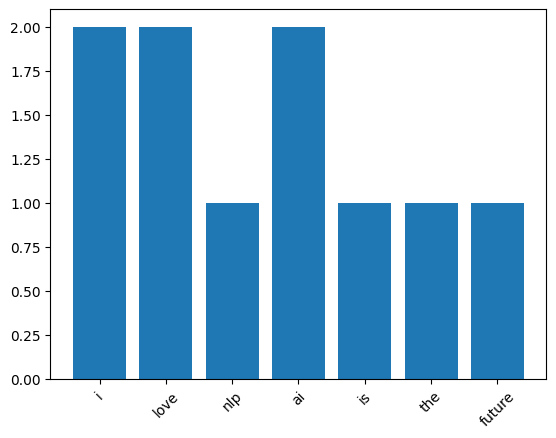

In [64]:
import matplotlib.pyplot as plt 

words = list(counter.keys())
freqs = list(counter.values())
# print(list(counter.values()))

plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.show()

---

#### **4.5 Zipf's Law Visualization**

7
[1 2 3 4 5 6 7]


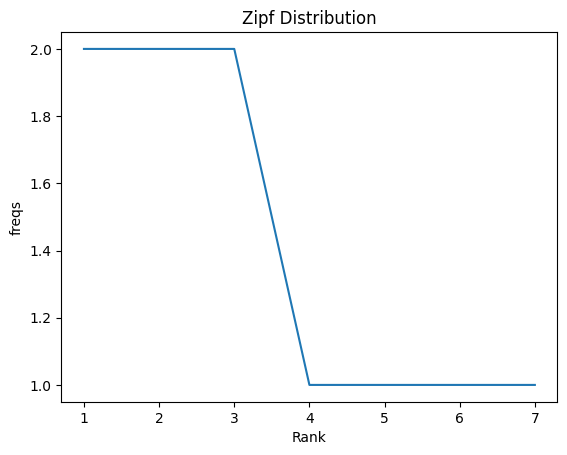

In [65]:
import numpy as np

freqs_sorted = sorted(freqs, reverse=True)
print(len(freqs_sorted))
ranks = np.arange(1, len(freqs_sorted)+1)
print(ranks)

plt.plot(ranks,freqs_sorted)
plt.xlabel("Rank")
plt.ylabel("freqs")
plt.title("Zipf Distribution")
plt.show()

---

# =========================================
# 5. GENAI / LLM / AGENT MAPPING
# =========================================

#### **In LLMs**

- Vocabulary is fixed after training
- Subword tokenization reduces OOV
- Token frequency impacts training dynamics

---

#### **In RAG Systems**

- Vocabulary affects:
    - Embeddings
    - Retrieval quality
- Rare word -> important for search relevance

---

#### **In AI Agents**

- Used in:
    - Query understanding
    - Memory indexing
    - Command parsing

---

#### **When Not Needed**

- High-level API usage
- Direct prompting

---

# =========================================
# 6. MINI PROJECT / TASK
# =========================================

#### **Project: Analyze Vocabulary Distribution**

**Input:** ["I love NLP", "NLP is powerful", "AI loves NLP"]

**Expected Output**

- Vocabulary dictionary
- Frequency distribution
- Zipf plot

**Steps**

1. Tokenize text
2. Build vocabulary
3. Count frequencies
4. Plot distribution
5. Analyze rare vs frequent words

---

#### **Vocabular Dictionary**

In [66]:
from collections import Counter

texts = ["I love NLP", "NLP is powerful", "AI loves NLP"]

def generate_vocab_freq(texts):
    tokens = []

    for text in texts:
        tokens.extend(text.split())

    counter = Counter(tokens)
    vocab = {word: idx for idx,(word,_) in enumerate(counter.items())}

    return vocab, counter    

vocab,counter = generate_vocab_freq(texts)

---

#### **Frequecny Distribution**

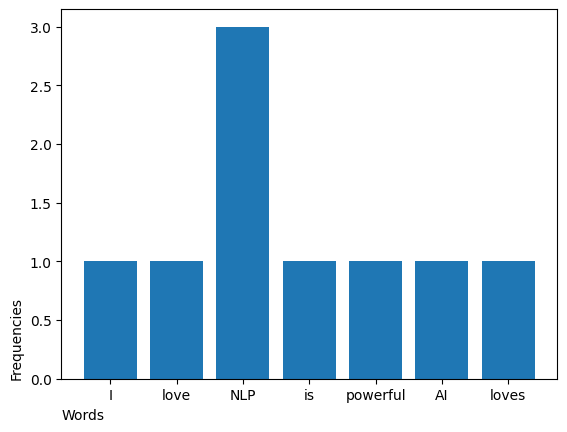

In [67]:
import matplotlib.pyplot as plt

words = list(counter.keys())
freqs = list(counter.values())

plt.bar(words,freqs)
plt.xlabel(xlabel="Words", loc='left')
plt.ylabel("Frequencies",loc='bottom')
plt.show()

---

#### **Zipf Plot**

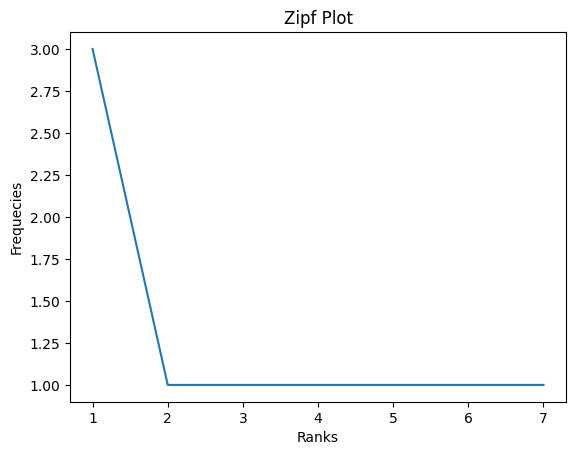

In [68]:
import numpy as np

freqs_sorted = sorted(freqs,reverse=True)
ranks = np.arange(1, len(freqs_sorted)+1)

plt.plot(ranks,freqs_sorted)
plt.xlabel("Ranks")
plt.ylabel("Frequecies")
plt.title("Zipf Plot")
plt.show()

---

# =========================================
# 7. LEARNINGS / SUMMARY
# =========================================

#### **Key Takeaways**

- Vocabulary defines model capability
- OOV is a core challenge
- Token distribution is highly skewed (zipf's Law)

---

#### **Important Insights**

- Few words dominate -> most words are rare
- Vocabulary size is a trade-off
- Subword tokenization solves many issues

---

#### **Common Mistakes**

- Ignoring rare words
- Choosing wrong vocab size
- Not handling OOV properly
- Overfitting to frequent tokens

---

# =========================================
# 8. SELF-TEST QUESTIONS
# =========================================

1. **Why does Zipf's Law matter while building NLP Systems?**

Zipf’s Law matters in NLP systems because it explains the highly skewed distribution of word frequencies in natural language, where a small number of words occur very frequently while the majority of words are rare. This insight helps in efficient vocabulary construction, as it allows us to prioritize high-frequency words that carry most of the linguistic signal while handling rare words separately. By focusing on frequent tokens, we can reduce vocabulary size, improve computational efficiency, and still retain most of the meaningful information in the corpus. Additionally, understanding this distribution highlights the long-tail problem, where many rare words contribute to OOV issues, which is why techniques like subword tokenization are used. Overall, Zipf’s Law guides better design decisions for balancing vocabulary size, performance, and coverage.

---

2. **What are the trade-offs on increasing vocbulary size?**

Increasing vocabulary size improves covergae and reduces the out of vocabulary problem, allowing the model to represent more words directly and capture finer grained semantics. However this comes at the cost of higher memory usage, increased computational complexity, and slower training and inferecne, as the model must manage a larger embedding matrix and perform lookups over a bigger space. On the other hand, a smaller vocabulary is more efficient and faster but suffers from high OOV rates and loss of information. Therefore, there is a trade-off between coverage and efficiency, and modern system address this by using subword tokenization to achieve a balance between the two.

---

3. **How do modern LLMs handle the OOV problem?**

Modern LLMs handle the OOV problem primarily through subword tokenization technique such as BPE, WordPiece and SentencePiece. Instead of relying on a fixed vocabulary of full words, these methods breaks word into smaller, reusable units, allowing the model to represent and understand the unseen or rare words by combining known subcomponents. This eliminates the need for a dedicated < UNK > token in most cases and significantly imporves generalization acros diverse and multilingual text. As a result, LLMs can effectively process almost any input text, even if specific words are not present in the training vocabulary.

---